##1

In [19]:
#!/usr/bin/env python
# coding: utf-8
!pip install pmlb

##2

In [20]:
import os
import sys
import time
import warnings
import openml
import socket
import concurrent.futures

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo
from pymfe.mfe import MFE
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import (cross_val_score, cross_validate, StratifiedKFold, RepeatedStratifiedKFold, KFold, LeaveOneOut)
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, StandardScaler
from sklearn.utils import resample
from sklearn.utils.multiclass import type_of_target

# --- Configurações Globais ---
os.environ["PYTHONWARNINGS"] = "ignore"
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
warnings.filterwarnings('ignore')


openml.config.apikey = "a53d4175d64b1ba34ce0bc8a63ee6ec8"

# Lock para gravação segura do CSV
print("✅ Imports carregados e ambiente configurado!")

✅ Imports carregados e ambiente configurado!


##3

In [16]:
arquivo_log = "checkpoint_meta_base.csv"

# Lista inicial de IDs do UCI (Vamos expandir isso depois)
datasets_ids = list(range(1, 451)) + [
    451, 458, 468, 469, 472, 476, 477, 485, 492, 493, 502, 504, 514, 519, 528, 529, 
    531, 536, 544, 545, 555, 560, 563, 571, 579, 591, 597, 601, 602, 603, 608, 
    622, 649, 683, 697, 713, 738, 754, 776, 797, 831, 848, 850, 866, 878, 879, 
    880, 887, 891, 901, 902, 915, 925, 936, 942, 
    1000, 1002, 1004, 1008, 1011, 1013, 1015, 1018, 1020, 1022, 1030, 1044, 
    1046, 1050, 1053, 1055, 1060, 1070, 1075, 1080, 1090, 1095,
    1100, 1101, 1104, 1106, 1111, 1115, 1120, 1130, 1140, 1160, 1200, 1250, 1300, 1400, 1500
]

print(f"📊 Total listado manualmente para o UCI: {len(datasets_ids)} datasets.")
print("--- INICIANDO PROCESSAMENTO VIA UCI (COM CHECKPOINT) ---\n")

# Modelos base e MFE
modelos_base = {
    'RF': RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1), 
    'SVM': SVC(random_state=42, max_iter=500, tol=1e-2), 
    'kNN': KNeighborsClassifier(n_jobs=-1),
    'LR': LogisticRegression(random_state=42, max_iter=200, solver='saga', tol=1e-2, n_jobs=-1),
    'NB': GaussianNB(),
    'DT': DecisionTreeClassifier(random_state=42)
}
cv_base = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

mfe = MFE(
    groups=["general", "statistical", "info-theory", "landmarking", "model-based", "complexity"],
    summary=["mean", "sd", "min", "max", "skewness", "kurtosis", "median", "iq_range"]
)

def processar_dataset(ds_id):
    dataset = fetch_ucirepo(id=ds_id)
    
    if dataset.data.targets is None:
        return f"ID {ds_id:<5} | {dataset.metadata.name[:15]:<15} | ⚠️ Pulado (Sem target definido)"
        
    X = dataset.data.features.copy()
    y = dataset.data.targets.copy()
    
    if isinstance(y, pd.DataFrame): 
        y = y.squeeze()
        
    # Tolerância bem mais alta para aproveitar a subamostragem
    if X.shape[0] > 100000 or X.shape[1] > 500:
        return f"ID {ds_id:<5} | {dataset.metadata.name[:15]:<15} | ⚠️ Pulado (Gigante: {X.shape})"

    X = X.dropna(axis=1, how='all')
    str_cols = X.select_dtypes(include=['object', 'string', 'category']).columns
    if len(str_cols) > 0:
        X[str_cols] = X[str_cols].astype(str).replace({'<NA>': np.nan, 'nan': np.nan})
        
    if pd.api.types.is_string_dtype(y) or pd.api.types.is_object_dtype(y):
        y = LabelEncoder().fit_transform(y)

    num_cols = X.select_dtypes(include=['int', 'float', 'number']).columns.tolist()
    cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

    preprocessor = ColumnTransformer(transformers=[
        ('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='mean')), ('scaler', StandardScaler())]), num_cols),
        ('cat', Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))]), cat_cols)
    ])

    TAMANHO_MAXIMO = 2000 
    if X.shape[0] > TAMANHO_MAXIMO:
        X_eval, y_eval = resample(X, y, n_samples=TAMANHO_MAXIMO, random_state=42, stratify=y)
    else:
        X_eval, y_eval = X, y

    best_acc, best_model = -1, None
    for nome_modelo, modelo in modelos_base.items():
        pipeline_avaliacao = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', modelo)])
        acc = np.mean(cross_val_score(pipeline_avaliacao, X_eval, y_eval, cv=cv_base, scoring='accuracy', n_jobs=-1))
        if acc > best_acc:
            best_acc, best_model = acc, nome_modelo

    X_mfe = preprocessor.fit_transform(X_eval) 
    mfe.fit(X_mfe, y_eval.to_numpy() if isinstance(y_eval, pd.Series) else y_eval) 
    ft_names, ft_values = mfe.extract()

    row = dict(zip(ft_names, ft_values))
    row['Dataset_ID'] = ds_id
    row['Dataset_Name'] = dataset.metadata.name
    row['MetaTarget'] = best_model
    
    arquivo_existe = os.path.exists(arquivo_log)
    cols = ['Dataset_ID', 'Dataset_Name', 'MetaTarget'] + ft_names
    pd.DataFrame([row], columns=cols).to_csv(arquivo_log, index=False, mode='a' if arquivo_existe else 'w', header=not arquivo_existe)

    return f"ID {ds_id:<5} | {dataset.metadata.name[:15]:<15} | Vencedor: {best_model:<4} | ✅ {len(ft_names)} features extraídas"


# ==========================================
# 3. LOOP PRINCIPAL COM TIMEOUT
# ==========================================
for ds_id in datasets_ids:
    
    # Checa o cache primeiro para não perder tempo
    if os.path.exists(arquivo_log):
        df_existente = pd.read_csv(arquivo_log, usecols=['Dataset_ID', 'Dataset_Name', 'MetaTarget'])
        if ds_id in df_existente['Dataset_ID'].values:
            nome_cache = df_existente.loc[df_existente['Dataset_ID'] == ds_id, 'Dataset_Name'].iloc[0]
            alvo_cache = df_existente.loc[df_existente['Dataset_ID'] == ds_id, 'MetaTarget'].iloc[0]
            print(f"ID {ds_id:<5} | {nome_cache[:15]:<15} | Vencedor: {alvo_cache:<4} | ⏭️ (Puxado do Cache)")
            continue

    # Executa a função com o limite de 5 minutos (300 segundos)
    try:
        with concurrent.futures.ThreadPoolExecutor(max_workers=1) as executor:
            futuro = executor.submit(processar_dataset, ds_id)
            # O "If" implícito: Se passar de 300 segundos, ele joga o erro e pula pro except
            resultado = futuro.result(timeout=300)
            print(resultado)
            
    except concurrent.futures.TimeoutError:
        print(f"ID {ds_id:<5} | ⏳ Timeout! Passou de 5 minutos. Pulando para o próximo...")
    except Exception as e:
        print(f"ID {ds_id:<5} | ❌ Erro: {str(e)[:60]}...")


# ==========================================
# 4. CARREGAMENTO FINAL PARA A PRÓXIMA CÉLULA
# ==========================================
print("\n--- FINALIZANDO ---")
if os.path.exists(arquivo_log):
    # Carrega a base salva para a variável df_meta
    df_meta = pd.read_csv(arquivo_log)
    
    # Limpeza final de NAs e Infinitos gerados pelo PyMFE
    df_meta.replace([np.inf, -np.inf], np.nan, inplace=True)
    
    # Dropa colunas que têm mais de 20% de valores nulos
    limite = int(0.8 * len(df_meta))
    df_meta = df_meta.dropna(axis=1, thresh=limite)
    
    # Preenche o resto dos nulos com a mediana da coluna
    num_cols = df_meta.select_dtypes(include=[np.number]).columns.drop('Dataset_ID', errors='ignore')
    if len(num_cols) > 0:
        df_meta[num_cols] = SimpleImputer(strategy='median').fit_transform(df_meta[num_cols])

    print(f"🎉 Extração concluída! A variável 'df_meta' está pronta para uso.")
    print(f"   Shape atual: {df_meta.shape[0]} instâncias x {df_meta.shape[1]} atributos.")
else:
    print("Nenhum dataset foi processado.")

📊 Total listado manualmente para o UCI: 542 datasets.
--- INICIANDO PROCESSAMENTO VIA UCI (COM CHECKPOINT) ---

ID 1     | Abalone         | Vencedor: RF   | ⏭️ (Puxado do Cache)
ID 2     | Adult           | Vencedor: LR   | ⏭️ (Puxado do Cache)
ID 3     | Annealing       | Vencedor: RF   | ⏭️ (Puxado do Cache)
ID 4     | ❌ Erro: "Anonymous Microsoft Web Data" dataset (id=4) exists in the ...
ID 5     | ❌ Erro: "Arrhythmia" dataset (id=5) exists in the repository, but is...
ID 6     | ❌ Erro: "Artificial Characters" dataset (id=6) exists in the reposit...
ID 7     | ❌ Erro: "Audiology (Original)" dataset (id=7) exists in the reposito...
ID 8     | Audiology (Stan | Vencedor: RF   | ⏭️ (Puxado do Cache)
ID 9     | ❌ Erro: Supported target types are: ('binary', 'multiclass'). Got 'c...
ID 10    | Automobile      | Vencedor: RF   | ⏭️ (Puxado do Cache)
ID 11    | ❌ Erro: "Badges" dataset (id=11) exists in the repository, but is no...
ID 12    | Balance Scale   | Vencedor: SVM  | ⏭️ (Puxad

##3.1

In [11]:
import os, time, concurrent.futures
import numpy as np, pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import resample
from pymfe.mfe import MFE

ARQ_PMLB = "checkpoint_pmlb.csv"
LIMITE_DATASETS = 200   # alto de proposito: pega todos os que conseguir
PMLB_BASE = "https://media.githubusercontent.com/media/EpistasisLab/pmlb/master/datasets"

modelos_base = {
    'RF': RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1),
    'SVM': SVC(random_state=42, max_iter=500, tol=1e-2),
    'kNN': KNeighborsClassifier(n_jobs=-1),
    'LR': LogisticRegression(random_state=42, max_iter=200, solver='saga', tol=1e-2, n_jobs=-1),
    'NB': GaussianNB(),
    'DT': DecisionTreeClassifier(random_state=42)
}
cv_base = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
mfe = MFE(groups=["general","statistical","info-theory","landmarking","model-based","complexity"],
          summary=["mean","sd","min","max","skewness","kurtosis","median","iq_range"])

# nomes ATUAIS, do arquivo de metadados oficial (corrige os 404)
STATS_URL = "https://raw.githubusercontent.com/EpistasisLab/pmlb/master/pmlb/all_summary_stats.tsv"
stats = pd.read_csv(STATS_URL, sep='\t')
clf = stats[(stats['task'] == 'classification') &
            (stats['n_instances'].between(100, 50000)) &
            (stats['n_features'].between(3, 500)) &
            (stats['n_classes'].between(2, 50))]
nomes_clf = clf['dataset'].tolist()
print(f"{len(nomes_clf)} datasets de classificacao disponiveis no PMLB.")

def processar_pmlb(nome):
    url = f"{PMLB_BASE}/{nome}/{nome}.tsv.gz"
    df = pd.read_csv(url, sep='\t', compression='gzip')
    y = df['target']; X = df.drop(columns=['target'])
    if y.nunique() < 2 or y.value_counts().min() < 3:
        return f"{nome[:28]:28s} | pulado (classe rara)"
    TAMANHO_MAXIMO = 2000
    if X.shape[0] > TAMANHO_MAXIMO:
        X_eval, y_eval = resample(X, y, n_samples=TAMANHO_MAXIMO, random_state=42, stratify=y)
    else:
        X_eval, y_eval = X, y
    best_acc, best_model = -1, None
    for nm, modelo in modelos_base.items():
        pipe = Pipeline([('sc', StandardScaler()), ('clf', modelo)])
        acc = np.mean(cross_val_score(pipe, X_eval, y_eval, cv=cv_base, scoring='accuracy', n_jobs=-1))
        if acc > best_acc:
            best_acc, best_model = acc, nm
    Xs = StandardScaler().fit_transform(X_eval)
    mfe.fit(Xs, y_eval.to_numpy())
    ft_names, ft_values = mfe.extract()
    row = dict(zip(ft_names, ft_values))
    row['Dataset_ID'] = f"pmlb_{nome}"
    row['Dataset_Name'] = nome
    row['MetaTarget'] = best_model
    existe = os.path.exists(ARQ_PMLB)
    cols = ['Dataset_ID','Dataset_Name','MetaTarget'] + ft_names
    pd.DataFrame([row], columns=cols).to_csv(ARQ_PMLB, index=False,
                                             mode='a' if existe else 'w', header=not existe)
    return f"{nome[:28]:28s} | vencedor: {best_model} | OK"

feitos = set()
if os.path.exists(ARQ_PMLB):
    feitos = set(pd.read_csv(ARQ_PMLB, usecols=['Dataset_ID'])['Dataset_ID'].values)
sucessos = len(feitos)
print(f"Ja na base: {sucessos}. Meta: {LIMITE_DATASETS}.")

for nome in nomes_clf:
    if sucessos >= LIMITE_DATASETS:
        break
    if f"pmlb_{nome}" in feitos:
        continue
    try:
        with concurrent.futures.ThreadPoolExecutor(max_workers=1) as ex:
            msg = ex.submit(processar_pmlb, nome).result(timeout=300)
        print(msg)
        if msg.endswith("OK"):
            sucessos += 1
    except concurrent.futures.TimeoutError:
        print(f"{nome[:28]:28s} | timeout, pulado")
    except Exception as e:
        print(f"{nome[:28]:28s} | erro: {str(e)[:45]}")

print(f"\nExtracao PMLB finalizada. Total na base: {sucessos}")

156 datasets de classificacao disponiveis no PMLB.
Ja na base: 122. Meta: 200.
_deprecated_australian       | vencedor: RF | OK
_deprecated_auto             | vencedor: RF | OK
_deprecated_breast           | vencedor: RF | OK
_deprecated_breast_cancer_wi | vencedor: SVM | OK
_deprecated_breast_w         | vencedor: RF | OK
_deprecated_buggyCrx         | vencedor: RF | OK
_deprecated_car              | vencedor: DT | OK
_deprecated_car_evaluation   | vencedor: DT | OK
_deprecated_cleve            | vencedor: SVM | OK
_deprecated_cleveland        | vencedor: kNN | OK
_deprecated_cleveland_nomina | vencedor: LR | OK
_deprecated_cmc              | vencedor: SVM | OK
_deprecated_colic            | vencedor: SVM | OK
_deprecated_contraceptive    | vencedor: SVM | OK
_deprecated_credit_a         | vencedor: RF | OK
_deprecated_credit_g         | vencedor: RF | OK
_deprecated_crx              | vencedor: RF | OK
_deprecated_diabetes         | vencedor: LR | OK
_deprecated_flare            | ve

##4 (new)

In [21]:
import os, glob
arquivos = sorted(glob.glob("checkpoint_*.csv"))
frames = [pd.read_csv(a) for a in arquivos]
df_meta = pd.concat(frames, ignore_index=True)

df_meta.replace([np.inf, -np.inf], np.nan, inplace=True)
df_meta = df_meta.dropna(axis=1, thresh=int(0.8 * len(df_meta)))
num_cols = df_meta.select_dtypes(include=[np.number]).columns.drop('Dataset_ID', errors='ignore')
if len(num_cols) > 0:
    df_meta[num_cols] = SimpleImputer(strategy='median').fit_transform(df_meta[num_cols])

print(f"Fontes: {arquivos}")
print(f"Meta-base: {df_meta.shape[0]} datasets x {df_meta.shape[1]} colunas")
print(df_meta['MetaTarget'].value_counts())

Fontes: ['checkpoint_meta_base.csv', 'checkpoint_pmlb.csv']
Meta-base: 271 datasets x 416 colunas
MetaTarget
RF     128
SVM     63
LR      37
DT      20
NB      12
kNN     11
Name: count, dtype: int64


##5

In [22]:
class MetaFeaturePruner:
    """Estágios de poda, do mais simples ao mais agressivo."""

    def v1_brute_force(self, X):
        # Baseline: nenhuma poda
        return np.arange(X.shape[1]), 0.0

    def v2_hard_pruning(self, X, y):
        # Supervisionado: mantém features acima da importância média da RF
        start = time.time()
        rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        rf.fit(X, y)
        idx = np.where(rf.feature_importances_ > rf.feature_importances_.mean())[0]
        return idx, time.time() - start

    def v3_variance_correlation(self, X, thr_corr=0.95):
        # NÃO-supervisionado: remove constantes e features redundantes (|r| > thr).
        # Dessatura o espaço ANTES do GA, que é onde estava o maior gargalo.
        start = time.time()
        Xdf = pd.DataFrame(X)
        keep = Xdf.columns[Xdf.nunique() > 1]          # tira constantes / quase-constantes
        Xdf = Xdf[keep]
        corr = Xdf.corr().abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        redundantes = [c for c in upper.columns if any(upper[c] > thr_corr)]
        final = np.array([k for k in keep if k not in redundantes])
        return final, time.time() - start


class GeneticFeatureSelector:
    """
    GA para seleção de meta-features. Convenção: 1 = feature presente, 0 = ausente.
    Correções principais:
      - fitness usa o MESMO avaliador da etapa final (RF50 + StratifiedKFold5)
      - penalidade de esparsidade com peso REAL (lambda), não placebo
      - população semeada com soluções heurísticas (full + top-k da RF)
      - mutação adaptativa: só sobe quando o melhor estagna
      - early-stopping por paciência no fitness
    """
    def __init__(self, n_splits=5, n_repeats=2, n_generations=80, pop_size=40,
                 crossover_prob=0.8, base_mutation=0.02, patience=12,
                 lam_sparsity=0.03, random_state=42):
        self.n_generations = n_generations
        self.pop_size = pop_size
        self.crossover_prob = crossover_prob
        self.base_mutation = base_mutation
        self.patience = patience
        self.lam = lam_sparsity
        self.random_state = random_state
        self.evaluator = RandomForestClassifier(n_estimators=50, random_state=random_state, n_jobs=-1)
        self.cv = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=random_state)
        self.history = []
        self.cache = {}

    def _fitness(self, X, y, chrom):
        key = chrom.tobytes()
        if key in self.cache:
            return self.cache[key]
        n_sel = int(chrom.sum())
        if n_sel == 0:
            self.cache[key] = (1e-6, 0)
            return self.cache[key]
        acc = np.mean(cross_val_score(self.evaluator, X[:, chrom == 1], y,
                                      cv=self.cv, scoring='balanced_accuracy', n_jobs=-1))
        fit = acc - self.lam * (n_sel / X.shape[1])   # penaliza tamanho de verdade
        self.cache[key] = (fit, n_sel)
        return self.cache[key]

    def _tournament(self, population, scores, k=3):
        pop = len(population)
        t = np.random.randint(0, pop, size=(pop, k))
        win = t[np.arange(pop), scores[t].argmax(axis=1)]
        return population[win]

    def fit_transform(self, X, y):
        start = time.time()
        np.random.seed(self.random_state)
        n = X.shape[1]
        pop = self.pop_size

        # Semeadura: full-set + top-k por importância da RF + aleatórios
        rf = RandomForestClassifier(n_estimators=100, random_state=self.random_state, n_jobs=-1).fit(X, y)
        order = np.argsort(rf.feature_importances_)[::-1]
        def topk(k):
            m = np.zeros(n, int); m[order[:k]] = 1; return m
        seeds = [np.ones(n, int), topk(max(3, n // 2)), topk(max(3, n // 3)), topk(max(3, n // 5))]
        rand = [np.random.choice([0, 1], size=n, p=[0.5, 0.5]) for _ in range(pop - len(seeds))]
        population = np.array(seeds + rand)

        best, best_fit, best_count, stale = None, -1, 0, 0
        print(f"        [GA] Pop {pop} | máx {self.n_generations} gen | {n} features de entrada")

        for g in range(self.n_generations):
            res = [self._fitness(X, y, ind) for ind in population]
            scores = np.array([r[0] for r in res])
            counts = np.array([r[1] for r in res])
            bi = scores.argmax()

            if scores[bi] > best_fit + 1e-9:
                best_fit, best, best_count, stale = scores[bi], population[bi].copy(), counts[bi], 0
            else:
                stale += 1

            self.history.append({'generation': g, 'best_fitness': best_fit, 'num_features': best_count})

            if g % 10 == 0 or g == self.n_generations - 1:
                print(f"        [GA] Gen {g:03d} | Fitness: {best_fit:.4f} | Ativas: {best_count:03d} | Estagnação: {stale}")

            if stale >= self.patience:
                print(f"        [GA] Early-stopping na geração {g} (sem melhora há {self.patience} gen).")
                break

            mut = self.base_mutation * (1 + 2 * stale / self.patience)   # adaptativa
            parents = self._tournament(population, scores, k=3)
            next_gen = [best.copy()]                                     # elitismo

            for i in range(0, pop - 1, 2):
                p1, p2 = parents[i], parents[(i + 1) % len(parents)]
                if np.random.rand() < self.crossover_prob:
                    mask = np.random.rand(n) > 0.5                       # crossover uniforme
                    c1, c2 = np.where(mask, p1, p2), np.where(mask, p2, p1)
                else:
                    c1, c2 = p1.copy(), p2.copy()
                c1 ^= (np.random.rand(n) < mut)
                c2 ^= (np.random.rand(n) < mut)
                next_gen.extend([c1, c2])

            population = np.array(next_gen)[:pop]

        final_indices = np.where(best == 1)[0]
        return final_indices, time.time() - start, self.history

##6

⚠️ Removidos 0 datasets de classes raras (<5). Restam 271.

--- INICIANDO TESTES DOS ESTÁGIOS ---
-> Otimização via GA sobre o espaço V3 (dessaturado)...
        [GA] Pop 40 | máx 80 gen | 278 features de entrada
        [GA] Gen 000 | Fitness: 0.3687 | Ativas: 055 | Estagnação: 0
        [GA] Gen 010 | Fitness: 0.3960 | Ativas: 092 | Estagnação: 2
        [GA] Gen 020 | Fitness: 0.3960 | Ativas: 092 | Estagnação: 12
        [GA] Early-stopping na geração 20 (sem melhora há 12 gen).
✅ Tabela de comparação salva em: 'resultados_tabela.csv'



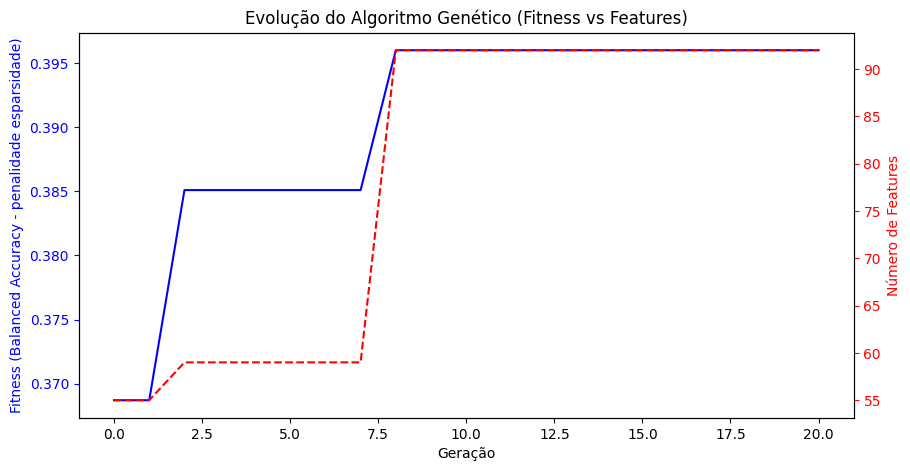

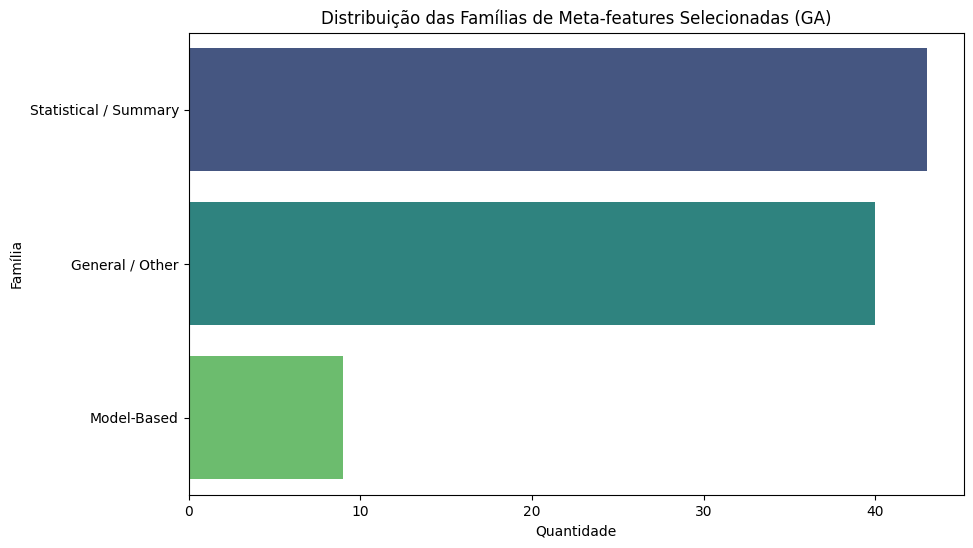


--- Analisando Importância RF vs Seleção GA ---


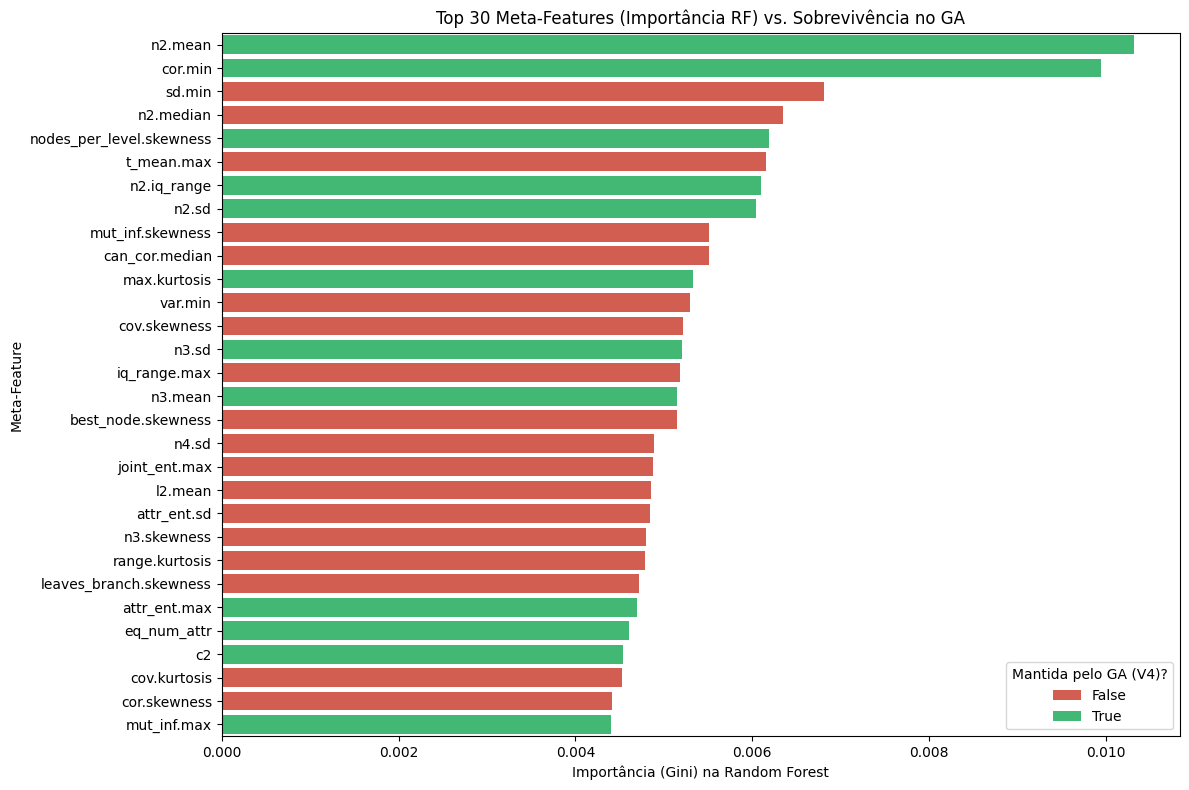


✅ Pipeline 100% finalizado! Verifique a sua pasta raiz para encontrar os 3 gráficos salvos.

=== RESUMO DOS RESULTADOS ===
             Modelo  Qtd_MFs_Sobreviventes  Tempo_Pruning(s)  Tempo_Total(s)  Acc_Balanceada  F1_Macro
   V1 (Força Bruta)                    413            0.0000          0.0000          0.3248    0.3247
  V2 (Hard Pruning)                    181            0.1704          0.1704          0.3811    0.3801
V3 (Var+Correlação)                    278            0.0965          0.0965          0.3229    0.3190
       V4 (V3 + GA)                     92            0.0965        149.6410          0.4224    0.4387


In [23]:
def executar_pipeline_wrapper(df_meta, arq_resultados="resultados_tabela.csv", arq_features="meta_features_v4.csv"):
    N_SPLITS = 5

    # Filtra classes com menos de N_SPLITS exemplos (senão StratifiedKFold é inválido).
    # No teu caso, remove os 2 datasets cujo vencedor foi 'NB'. Documente isso no relatório.
    vc = df_meta['MetaTarget'].value_counts()
    classes_ok = vc[vc >= N_SPLITS].index
    removidos = df_meta[~df_meta['MetaTarget'].isin(classes_ok)].shape[0]
    df_meta = df_meta[df_meta['MetaTarget'].isin(classes_ok)].reset_index(drop=True)
    print(f"⚠️ Removidos {removidos} datasets de classes raras (<{N_SPLITS}). Restam {len(df_meta)}.\n")

    colunas_ignorar = ['Dataset_ID', 'Dataset_Name', 'MetaTarget']
    X_meta = df_meta.drop(columns=[c for c in colunas_ignorar if c in df_meta.columns]).values
    y_meta = LabelEncoder().fit_transform(df_meta['MetaTarget'])
    meta_cols = df_meta.drop(columns=[c for c in colunas_ignorar if c in df_meta.columns]).columns.tolist()

    cv_eval = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
    final_clf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
    metricas = ['balanced_accuracy', 'f1_macro']
    resultados = []
    pruner = MetaFeaturePruner()

    print("--- INICIANDO TESTES DOS ESTÁGIOS ---")
    idx_v1, t_v1 = pruner.v1_brute_force(X_meta)
    sc = cross_validate(final_clf, X_meta[:, idx_v1], y_meta, cv=cv_eval, scoring=metricas)
    acc_v1, f1_v1 = np.mean(sc['test_balanced_accuracy']), np.mean(sc['test_f1_macro'])

    idx_v2, t_v2 = pruner.v2_hard_pruning(X_meta, y_meta)
    sc = cross_validate(final_clf, X_meta[:, idx_v2], y_meta, cv=cv_eval, scoring=metricas)
    acc_v2, f1_v2 = np.mean(sc['test_balanced_accuracy']), np.mean(sc['test_f1_macro'])

    idx_v3, t_v3 = pruner.v3_variance_correlation(X_meta, thr_corr=0.95)
    sc = cross_validate(final_clf, X_meta[:, idx_v3], y_meta, cv=cv_eval, scoring=metricas)
    acc_v3, f1_v3 = np.mean(sc['test_balanced_accuracy']), np.mean(sc['test_f1_macro'])

    # V4: GA roda no espaço JÁ dessaturado (V3), não nas 469 cruas
    print("-> Otimização via GA sobre o espaço V3 (dessaturado)...")
    X_v3 = X_meta[:, idx_v3]
    ga = GeneticFeatureSelector(n_splits=N_SPLITS, n_generations=80, random_state=42)
    idx_ga_relativo, t_ga, ga_history = ga.fit_transform(X_v3, y_meta)
    idx_v4_absoluto = idx_v3[idx_ga_relativo]
    sc = cross_validate(final_clf, X_meta[:, idx_v4_absoluto], y_meta, cv=cv_eval, scoring=metricas)
    acc_v4, f1_v4 = np.mean(sc['test_balanced_accuracy']), np.mean(sc['test_f1_macro'])

    features_v4_nomes = [meta_cols[i] for i in idx_v4_absoluto]
    pd.DataFrame({"Meta_Features_Sobreviventes_V4": features_v4_nomes}).to_csv(arq_features, index=False)

    modelos_info = [
        ('V1 (Força Bruta)', len(idx_v1), t_v1, t_v1, acc_v1, f1_v1),
        ('V2 (Hard Pruning)', len(idx_v2), t_v2, t_v2, acc_v2, f1_v2),
        ('V3 (Var+Correlação)', len(idx_v3), t_v3, t_v3, acc_v3, f1_v3),
        ('V4 (V3 + GA)', len(idx_v4_absoluto), t_v3, t_v3 + t_ga, acc_v4, f1_v4),
    ]
    
    for nome, qtd, tp, tt, acc, f1 in modelos_info:
        resultados.append({
            'Modelo': nome, 
            'Qtd_MFs_Sobreviventes': qtd,
            'Tempo_Pruning(s)': round(tp, 4), 
            'Tempo_Total(s)': round(tt, 4),
            'Acc_Balanceada': round(acc, 4),
            'F1_Macro': round(f1, 4)
        })
        
    df_resultados = pd.DataFrame(resultados)
    df_resultados.to_csv(arq_resultados, index=False)
    print(f"✅ Tabela de comparação salva em: '{arq_resultados}'\n")
    
    # =====================================================================
    # 4. GRÁFICOS E ANÁLISE VISUAL
    # =====================================================================
    
    # Gráfico 1: Evolução do GA
    history_df = pd.DataFrame(ga_history)
    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax1.plot(history_df['generation'], history_df['best_fitness'], 'b-')
    ax1.set_xlabel('Geração')
    ax1.set_ylabel('Fitness (Balanced Accuracy - penalidade esparsidade)', color='b')
    ax1.tick_params('y', colors='b')
    
    ax2 = ax1.twinx()
    ax2.plot(history_df['generation'], history_df['num_features'], 'r--')
    ax2.set_ylabel('Número de Features', color='r')
    ax2.tick_params('y', colors='r')
    
    plt.title('Evolução do Algoritmo Genético (Fitness vs Features)')
    plt.savefig('grafico_1_evolucao_ga.png', dpi=300, bbox_inches='tight') 
    plt.show()

    # Gráfico 2: Famílias de Meta-Features
    def extrair_grupo(nome):
        if 'mean' in nome or 'sd' in nome or 'min' in nome or 'max' in nome: return 'Statistical / Summary'
        elif 'attrEnt' in nome or 'mutInf' in nome or 'classEnt' in nome or 'jointEnt' in nome: return 'Info-Theory'
        elif 'bestNode' in nome or 'eliteNN' in nome or 'linearDiscr' in nome or 'naiveBayes' in nome or 'oneNN' in nome or 'randomNode' in nome or 'worstNode' in nome: return 'Landmarking'
        elif 'leaves' in nome or 'tree' in nome or 'nodes' in nome or 'varImportance' in nome: return 'Model-Based'
        else: return 'General / Other'

    df_familias = pd.DataFrame({"Nome": features_v4_nomes})
    df_familias['Grupo'] = df_familias['Nome'].apply(extrair_grupo)

    plt.figure(figsize=(10, 6))
    sns.countplot(data=df_familias, y='Grupo', order=df_familias['Grupo'].value_counts().index, palette='viridis')
    plt.title('Distribuição das Famílias de Meta-features Selecionadas (GA)')
    plt.xlabel('Quantidade')
    plt.ylabel('Família')
    plt.savefig('grafico_2_familias_mf.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Gráfico 3: RF vs GA
    print("\n--- Analisando Importância RF vs Seleção GA ---")
    rf_analise = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_analise.fit(X_meta, y_meta)

    df_importances = pd.DataFrame({
        'Meta_Feature': meta_cols,
        'Importancia_RF': rf_analise.feature_importances_
    })
    df_importances['Mantida_pelo_GA'] = df_importances['Meta_Feature'].isin(features_v4_nomes)
    top_30_rf = df_importances.sort_values(by='Importancia_RF', ascending=False).head(30)

    plt.figure(figsize=(12, 8))
    sns.barplot(
        data=top_30_rf, x='Importancia_RF', y='Meta_Feature', 
        hue='Mantida_pelo_GA', dodge=False, palette={True: '#2ecc71', False: '#e74c3c'}
    )
    plt.title('Top 30 Meta-Features (Importância RF) vs. Sobrevivência no GA')
    plt.xlabel('Importância (Gini) na Random Forest')
    plt.ylabel('Meta-Feature')
    plt.legend(title='Mantida pelo GA (V4)?', loc='lower right')
    plt.tight_layout()
    plt.savefig('grafico_3_rf_vs_ga.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✅ Pipeline 100% finalizado! Verifique a sua pasta raiz para encontrar os 3 gráficos salvos.")
    return df_resultados

# =====================================================================
# INICIALIZAÇÃO
# =====================================================================
df_final = executar_pipeline_wrapper(df_meta)
print("\n=== RESUMO DOS RESULTADOS ===")
print(df_final.to_string(index=False))

##6.1

In [24]:
from sklearn.metrics import balanced_accuracy_score, f1_score
import time

def avaliacao_aninhada(df_meta, n_outer=5, inner_splits=3, n_repeats=2,
                       ga_generations=40, pop_size=24, seed=42):
    """
    Validacao ANINHADA: a selecao de features (pruner + GA) roda SO no treino
    de cada fold externo, e a avaliacao e feita no teste que a selecao nunca viu.
    Corrige o vies de selecao (vazamento) da avaliacao ingenua.
    """
    N_SPLITS = 5
    vc = df_meta['MetaTarget'].value_counts()
    df_f = df_meta[df_meta['MetaTarget'].isin(vc[vc >= N_SPLITS].index)].reset_index(drop=True)
    ign = ['Dataset_ID', 'Dataset_Name', 'MetaTarget']
    X = df_f.drop(columns=[c for c in ign if c in df_f.columns]).values
    y = LabelEncoder().fit_transform(df_f['MetaTarget'])

    outer = StratifiedKFold(n_splits=n_outer, shuffle=True, random_state=seed)
    pruner = MetaFeaturePruner()
    res = {k: {'b': [], 'f': [], 'n': []} for k in ['V1', 'V2', 'V4']}

    def aval(Xtr, Xte, ytr, yte, idx):
        clf = RandomForestClassifier(n_estimators=50, random_state=seed, n_jobs=-1).fit(Xtr[:, idx], ytr)
        p = clf.predict(Xte[:, idx])
        return balanced_accuracy_score(yte, p), f1_score(yte, p, average='macro')

    t0 = time.time()
    for fold, (tr, te) in enumerate(outer.split(X, y)):
        Xtr, Xte, ytr, yte = X[tr], X[te], y[tr], y[te]

        # V1: sem selecao (nao ha vazamento possivel)
        idx = np.arange(Xtr.shape[1]); b, f = aval(Xtr, Xte, ytr, yte, idx)
        res['V1']['b'].append(b); res['V1']['f'].append(f); res['V1']['n'].append(len(idx))

        # V2: hard pruning so no treino do fold
        idx, _ = pruner.v2_hard_pruning(Xtr, ytr); b, f = aval(Xtr, Xte, ytr, yte, idx)
        res['V2']['b'].append(b); res['V2']['f'].append(f); res['V2']['n'].append(len(idx))

        # V4: V3 (correlacao) + GA, tudo so no treino do fold
        idx3, _ = pruner.v3_variance_correlation(Xtr, thr_corr=0.95)
        ga = GeneticFeatureSelector(n_splits=inner_splits, n_repeats=n_repeats,
                                    n_generations=ga_generations, pop_size=pop_size, random_state=seed)
        rel, _, _ = ga.fit_transform(Xtr[:, idx3], ytr)
        idx4 = idx3[rel]; b, f = aval(Xtr, Xte, ytr, yte, idx4)
        res['V4']['b'].append(b); res['V4']['f'].append(f); res['V4']['n'].append(len(idx4))

        print(f"  Fold {fold}: V4 {len(idx4):3d} feats | bAcc={b:.3f} | {time.time()-t0:.0f}s")

    print("\n=== VALIDACAO ANINHADA (honesta, sem vazamento) ===")
    linhas = []
    for k in ['V1', 'V2', 'V4']:
        mb, sb = np.mean(res[k]['b']), np.std(res[k]['b'])
        mf, mn = np.mean(res[k]['f']), np.mean(res[k]['n'])
        print(f"  {k} | MFs~{mn:.0f} | bAcc={mb:.4f} +- {sb:.3f} | F1={mf:.4f}")
        linhas.append({'Modelo': k, 'MFs_media': round(mn, 1),
                       'bAcc_media': round(mb, 4), 'bAcc_std': round(sb, 4), 'F1_media': round(mf, 4)})
    pd.DataFrame(linhas).to_csv("resultados_aninhado.csv", index=False)
    return res

res_aninhado = avaliacao_aninhada(df_meta)

        [GA] Pop 24 | máx 40 gen | 274 features de entrada
        [GA] Gen 000 | Fitness: 0.3131 | Ativas: 054 | Estagnação: 0
        [GA] Gen 010 | Fitness: 0.3131 | Ativas: 054 | Estagnação: 10
        [GA] Early-stopping na geração 12 (sem melhora há 12 gen).
  Fold 0: V4  54 feats | bAcc=0.403 | 38s
        [GA] Pop 24 | máx 40 gen | 275 features de entrada
        [GA] Gen 000 | Fitness: 0.3921 | Ativas: 055 | Estagnação: 0
        [GA] Gen 010 | Fitness: 0.3973 | Ativas: 085 | Estagnação: 3
        [GA] Gen 020 | Fitness: 0.4045 | Ativas: 111 | Estagnação: 0
        [GA] Gen 030 | Fitness: 0.4287 | Ativas: 102 | Estagnação: 9
        [GA] Early-stopping na geração 33 (sem melhora há 12 gen).
  Fold 1: V4 102 feats | bAcc=0.269 | 138s
        [GA] Pop 24 | máx 40 gen | 310 features de entrada
        [GA] Gen 000 | Fitness: 0.3298 | Ativas: 062 | Estagnação: 0
        [GA] Gen 010 | Fitness: 0.3449 | Ativas: 081 | Estagnação: 3
        [GA] Gen 020 | Fitness: 0.3452 | Ativas: 10

##6.2

In [25]:
from scipy.stats import wilcoxon, ttest_rel

def teste_hipotese(res):
    print("Teste pareado entre estagios (acuracia balanceada por fold):\n")
    for a, b in [('V1','V4'), ('V1','V2'), ('V2','V4')]:
        ba, bb = np.array(res[a]['b']), np.array(res[b]['b'])
        dif = (bb - ba).mean()
        _, p_t = ttest_rel(bb, ba)
        try:
            _, p_w = wilcoxon(bb, ba)
        except ValueError:
            p_w = float('nan')
        sig = "SIGNIFICATIVO" if p_t < 0.05 else "nao significativo"
        print(f"  {b} vs {a}: diff media={dif:+.4f} | t-test p={p_t:.3f} | wilcoxon p={p_w:.3f}  -> {sig}")
    print(f"\n  (n={len(res['V1']['b'])} folds. p<0.05 = diferenca estatisticamente significativa)")

teste_hipotese(res_aninhado)

Teste pareado entre estagios (acuracia balanceada por fold):

  V4 vs V1: diff media=+0.0140 | t-test p=0.296 | wilcoxon p=0.438  -> nao significativo
  V2 vs V1: diff media=+0.0091 | t-test p=0.610 | wilcoxon p=0.812  -> nao significativo
  V4 vs V2: diff media=+0.0049 | t-test p=0.821 | wilcoxon p=1.000  -> nao significativo

  (n=5 folds. p<0.05 = diferenca estatisticamente significativa)


##7

In [26]:
from collections import Counter
import itertools

def analise_estabilidade(df_meta, seeds=(42, 7, 123), n_repeats=2, arq="estabilidade_features.csv"):
    N_SPLITS = 5
    vc = df_meta['MetaTarget'].value_counts()
    df_meta = df_meta[df_meta['MetaTarget'].isin(vc[vc >= N_SPLITS].index)].reset_index(drop=True)

    ign = ['Dataset_ID', 'Dataset_Name', 'MetaTarget']
    X_meta = df_meta.drop(columns=[c for c in ign if c in df_meta.columns]).values
    y_meta = LabelEncoder().fit_transform(df_meta['MetaTarget'])
    meta_cols = df_meta.drop(columns=[c for c in ign if c in df_meta.columns]).columns.tolist()

    pruner = MetaFeaturePruner()
    idx_v3, _ = pruner.v3_variance_correlation(X_meta, thr_corr=0.95)
    X_v3 = X_meta[:, idx_v3]

    runs, freq = [], Counter()
    print(f"Rodando o GA com {len(seeds)} sementes diferentes...\n")
    for s in seeds:
        ga = GeneticFeatureSelector(n_splits=N_SPLITS, n_repeats=n_repeats,
                                    n_generations=80, random_state=s)
        rel, _, _ = ga.fit_transform(X_v3, y_meta)
        feats = set(idx_v3[rel].tolist())
        runs.append(feats)
        for f in feats:
            freq[f] += 1
        print(f"  Semente {s:>4}: {len(feats)} features selecionadas\n")

    k = len(seeds)
    consenso = sorted(f for f, c in freq.items() if c == k)
    maioria  = sorted(f for f, c in freq.items() if c >= (k // 2 + 1))
    jaccard = np.mean([len(a & b) / len(a | b) for a, b in itertools.combinations(runs, 2)])

    # Tabela de frequência (quantas rodadas mantiveram cada feature)
    df_freq = pd.DataFrame({
        'Meta_Feature': [meta_cols[i] for i in freq],
        'Vezes_Selecionada': [freq[i] for i in freq]
    }).sort_values('Vezes_Selecionada', ascending=False)
    df_freq.to_csv(arq, index=False)

    print("=" * 55)
    print(f"Jaccard médio entre pares : {jaccard:.3f}  (acaso ~0.14)")
    print(f"Selecionadas em TODAS ({k}/{k}) : {len(consenso)} features")
    print(f"Selecionadas pela maioria      : {len(maioria)} features")

    # Avalia os conjuntos estáveis
    fc = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
    for nome, fs in [("Consenso", consenso), ("Maioria", maioria)]:
        if fs:
            sc = cross_validate(fc, X_meta[:, fs], y_meta, cv=cv,
                                scoring=['balanced_accuracy', 'f1_macro'])
            print(f"  {nome:9s} | MFs={len(fs):3d} | "
                  f"bAcc={np.mean(sc['test_balanced_accuracy']):.4f} | "
                  f"F1={np.mean(sc['test_f1_macro']):.4f}")
    return df_freq

df_freq = analise_estabilidade(df_meta)

Rodando o GA com 3 sementes diferentes...

        [GA] Pop 40 | máx 80 gen | 278 features de entrada
        [GA] Gen 000 | Fitness: 0.3687 | Ativas: 055 | Estagnação: 0
        [GA] Gen 010 | Fitness: 0.3960 | Ativas: 092 | Estagnação: 2
        [GA] Gen 020 | Fitness: 0.3960 | Ativas: 092 | Estagnação: 12
        [GA] Early-stopping na geração 20 (sem melhora há 12 gen).
  Semente   42: 92 features selecionadas

        [GA] Pop 40 | máx 80 gen | 278 features de entrada
        [GA] Gen 000 | Fitness: 0.3969 | Ativas: 055 | Estagnação: 0
        [GA] Gen 010 | Fitness: 0.3969 | Ativas: 055 | Estagnação: 10
        [GA] Early-stopping na geração 12 (sem melhora há 12 gen).
  Semente    7: 55 features selecionadas

        [GA] Pop 40 | máx 80 gen | 278 features de entrada
        [GA] Gen 000 | Fitness: 0.3811 | Ativas: 055 | Estagnação: 0
        [GA] Gen 010 | Fitness: 0.3883 | Ativas: 061 | Estagnação: 7
        [GA] Early-stopping na geração 15 (sem melhora há 12 gen).
  Semente 

##8

In [27]:
# =====================================================================
# RESUMO CONSOLIDADO - rode por ultimo, copie a saida inteira
# =====================================================================
def resumo_consolidado(df_meta):
    linhas = []
    P = linhas.append
    N_SPLITS = 5

    # --- Meta-base ---
    vc_total = df_meta['MetaTarget'].value_counts()
    raras = vc_total[vc_total < N_SPLITS]
    df_f = df_meta[df_meta['MetaTarget'].isin(vc_total[vc_total >= N_SPLITS].index)].reset_index(drop=True)
    n_mf = df_meta.shape[1] - 3

    P("=" * 60)
    P("RESUMO CONSOLIDADO - PROJETO META-APRENDIZAGEM (TEMA 4)")
    P("=" * 60)
    P("\n[META-BASE]")
    P(f"  Datasets totais        : {len(df_meta)}")
    P(f"  Meta-features cruas     : {n_mf}")
    P(f"  Classes removidas (<{N_SPLITS}) : {list(raras.index)} ({raras.sum()} datasets)")
    P(f"  Datasets usados         : {len(df_f)}")
    P(f"  Distribuicao das classes (apos filtro):")
    for cls, n in df_f['MetaTarget'].value_counts().items():
        P(f"      {cls:<5}: {n}")

    # --- Tabela V1-V4 ---
    P("\n[COMPARACAO DOS ESTAGIOS DE PODA]")
    try:
        tab = pd.read_csv("resultados_tabela.csv")
        P(tab.to_string(index=False))
    except Exception as e:
        P(f"  (resultados_tabela.csv nao encontrado: {e})")

    # --- Estabilidade multi-seed ---
    P("\n[ESTABILIDADE DA SELECAO (multi-seed)]")
    try:
        freq = pd.read_csv("estabilidade_features.csv")
        n_seeds = int(freq['Vezes_Selecionada'].max())
        consenso = freq[freq['Vezes_Selecionada'] == n_seeds]['Meta_Feature'].tolist()
        maioria  = freq[freq['Vezes_Selecionada'] >= (n_seeds // 2 + 1)]['Meta_Feature'].tolist()
        P(f"  Sementes executadas     : {n_seeds}")
        P(f"  Consenso ({n_seeds}/{n_seeds})         : {len(consenso)} features")
        P(f"  Maioria (>= {n_seeds // 2 + 1})           : {len(maioria)} features")

        ign = ['Dataset_ID', 'Dataset_Name', 'MetaTarget']
        y = LabelEncoder().fit_transform(df_f['MetaTarget'])
        fc = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
        cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
        for nome, fs in [("Consenso", consenso), ("Maioria", maioria)]:
            cols_ok = [c for c in fs if c in df_f.columns]
            if cols_ok:
                Xs = df_f[cols_ok].values
                sc = cross_validate(fc, Xs, y, cv=cv, scoring=['balanced_accuracy', 'f1_macro'])
                P(f"  {nome:9s} | MFs={len(cols_ok):3d} | "
                  f"bAcc={np.mean(sc['test_balanced_accuracy']):.4f} | "
                  f"F1={np.mean(sc['test_f1_macro']):.4f}")
        P(f"\n  Top 15 meta-features por frequencia de selecao:")
        for _, r in freq.head(15).iterrows():
            P(f"      {r['Meta_Feature']:<35} {int(r['Vezes_Selecionada'])}/{n_seeds}")
    except Exception as e:
        P(f"  (estabilidade_features.csv nao encontrado: {e})")

    # --- Familias do conjunto V4 ---
    P("\n[FAMILIAS DAS META-FEATURES V4]")
    try:
        v4 = pd.read_csv("meta_features_v4.csv")["Meta_Features_Sobreviventes_V4"].tolist()
        def grupo(n):
            if any(k in n for k in ['mean','sd','min','max','median','iq_range','skewness','kurtosis']): return 'Statistical/Summary'
            if any(k in n for k in ['attrEnt','mutInf','classEnt','jointEnt','ent','Inf']): return 'Info-Theory'
            if any(k in n for k in ['bestNode','eliteNN','linearDiscr','naiveBayes','oneNN','randomNode','worstNode','Landmark']): return 'Landmarking'
            if any(k in n for k in ['leaves','tree','nodes','varImportance']): return 'Model-Based'
            return 'General/Other'
        cont = Counter(grupo(n) for n in v4)
        P(f"  Total no conjunto V4: {len(v4)} features")
        for g, c in cont.most_common():
            P(f"      {g:<20}: {c}")
    except Exception as e:
        P(f"  (meta_features_v4.csv nao encontrado: {e})")

    P("\n" + "=" * 60)
    print("\n".join(linhas))

resumo_consolidado(df_meta)

RESUMO CONSOLIDADO - PROJETO META-APRENDIZAGEM (TEMA 4)

[META-BASE]
  Datasets totais        : 271
  Meta-features cruas     : 413
  Classes removidas (<5) : [] (0 datasets)
  Datasets usados         : 271
  Distribuicao das classes (apos filtro):
      RF   : 128
      SVM  : 63
      LR   : 37
      DT   : 20
      NB   : 12
      kNN  : 11

[COMPARACAO DOS ESTAGIOS DE PODA]
             Modelo  Qtd_MFs_Sobreviventes  Tempo_Pruning(s)  Tempo_Total(s)  Acc_Balanceada  F1_Macro
   V1 (Força Bruta)                    413            0.0000          0.0000          0.3248    0.3247
  V2 (Hard Pruning)                    181            0.1704          0.1704          0.3811    0.3801
V3 (Var+Correlação)                    278            0.0965          0.0965          0.3229    0.3190
       V4 (V3 + GA)                     92            0.0965        149.6410          0.4224    0.4387

[ESTABILIDADE DA SELECAO (multi-seed)]
  Sementes executadas     : 3
  Consenso (3/3)         : 21 feat